# Imports

In [1]:
import torch
import torchvision
from torchvision.models import resnet18, densenet121
from torchvision.transforms import v2
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random

In [2]:
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: mps


In [3]:
# torchvision expects the parent folder of cifar-10-batches-py.
cifar10data = '/Users/jup9x/Documents/Deep learning/PGR207-1-26H-Deep-Learning-Assignment'
print(f"Using existing CIFAR-10 dataset from: {cifar10data}")

Using existing CIFAR-10 dataset from: /Users/jup9x/Documents/Deep learning/PGR207-1-26H-Deep-Learning-Assignment


# Defining Three Architectures

In [4]:
# (I'll remove name later)
# Note for julien: Baseline, no change needed
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Note for julien: I'll change this one
def get_cifar_resnet18():
    model = resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)            # Replace the initial 7x7 convolution with a smaller 3x3 convolution
    model.maxpool = nn.Identity()                                                             # Remove the max pooling layer
    return model

# Note for julien: You change this one
def get_cifar_densenet121():
    model = densenet121(weights=None, num_classes=10)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)   # Modify the first convolutional layer and pooling for 32x32 inputs
    model.features.pool0 = nn.Identity()
    return model

architectures = {
    "baseline_simple_cnn": SimpleCNN,
    "resnet18": get_cifar_resnet18,
    "densenet121": get_cifar_densenet121
}

# Defining Three Augmentations

In [5]:
base_ops = [
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]

augmentation_strategies = {
    # Note for julien: Baseline, no change needed
    "baseline_augmentation": v2.Compose(base_ops),

    # Note for julien: I'll change this one
    "aug1": v2.Compose([
        v2.ToImage(),
        v2.RandomCrop(32, padding=4),
        v2.RandomHorizontalFlip(),
        *base_ops[1:]
    ]),

    # Note for julien: You change this one
    "aug2": v2.Compose([
        v2.ToImage(),
        v2.RandomCrop(32, padding=4),
        v2.RandomHorizontalFlip(),
        v2.RandAugment(num_ops=2, magnitude=9),
        *base_ops[1:]
    ])
}

# Defining Three Optimizers

In [6]:
optimizers = {
    # Note for julien: Baseline, no change needed
    "baseline_sgd_momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    # Note for julien: I'll change this one
    "adam": lambda params: optim.Adam(params, lr=0.01),
    # Note for julien: You change this one
    "adamw": lambda params: optim.AdamW(params, lr=0.01, weight_decay=0.01)
}

# Selecting Configuration

In [7]:
# Every row changes only one factor relative to Baseline.
configurations = {
    "Baseline": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "ResNet18": {"arch": "resnet18", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "DenseNet121": {"arch": "densenet121", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "Aug1": {"arch": "baseline_simple_cnn", "aug": "aug1", "opt": "baseline_sgd_momentum"},
    "Aug2": {"arch": "baseline_simple_cnn", "aug": "aug2", "opt": "baseline_sgd_momentum"},
    "Adam": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "adam"},
    "AdamW": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "adamw"}
}
train_transform = augmentation_strategies[configurations["Baseline"]["aug"]]

# 1 Pre Processing

## 1.2 Seeding

In [8]:
experiment_seeds = [0, 1, 2]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)  # Also seeds MPS when available

current_seed = experiment_seeds[0]
set_seed(current_seed)

## 1.3 CIFAR-10 Dataset

### 1.3.1 Downloading and Tranforming

In [9]:
# Transform for validation and test data (NO augmentations)
eval_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_trainset_aug = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=False, transform=train_transform)
full_trainset_eval = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=False, transform=eval_transform)

from sklearn.model_selection import train_test_split

# One fixed class-stratified split, shared by all configurations and seeds.
train_idx, val_idx = train_test_split(
    np.arange(len(full_trainset_aug)), test_size=0.1, random_state=42,
    stratify=full_trainset_aug.targets
)

trainset = torch.utils.data.Subset(full_trainset_aug, train_idx)    # map the training indices to the augmented data
valset = torch.utils.data.Subset(full_trainset_eval, val_idx)       # map the valuation indices to the normalized data

# The test set only uses the evaluation transform
testset = torchvision.datasets.CIFAR10(root=cifar10data, train=False, download=False, transform=eval_transform)

In [10]:
batch_size = 64
num_workers = 0  # Reliable for a local macOS notebook

### 1.3.2 Step by Step Inspection for understanding underlying data

In [11]:
print("--Before Transformation Shape and Dtype--\n ---------------------------------------")
from PIL import Image
pimg = Image.fromarray(full_trainset_aug.data[0])
plabel = full_trainset_aug.targets[0]
print(type(pimg))
print(f"Size (W, H): {pimg.size}")
print(f"Mode: {pimg.mode}")

print("\n--After Transformation Shape and Dtype--\n ---------------------------------------")
img, label = trainset[0]
print(type(img))
print(img.shape)
print(img.dtype)

step1_to_image = v2.ToImage()
step2_to_dtype = v2.ToDtype(torch.float32, scale=True)
step3_normalize = v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

img_t1 = step1_to_image(pimg)
img_t2 = step2_to_dtype(img_t1)
img_t3 = step3_normalize(img_t2)

print("\n-- Step-by-Step --")
print(f"After ToImage:   type={type(img_t1)}, shape={img_t1.shape}, dtype={img_t1.dtype}, min={img_t1.min()}, max={img_t1.max()}")
print(f"After ToDtype:   type={type(img_t2)}, shape={img_t2.shape}, dtype={img_t2.dtype}, min={img_t2.min():.2f}, max={img_t2.max():.2f}")
print(f"After Normalize: type={type(img_t3)}, shape={img_t3.shape}, dtype={img_t3.dtype}, min={img_t3.min():.2f}, max={img_t3.max():.2f}")

--Before Transformation Shape and Dtype--
 ---------------------------------------
<class 'PIL.Image.Image'>
Size (W, H): (32, 32)
Mode: RGB

--After Transformation Shape and Dtype--
 ---------------------------------------
<class 'torchvision.tv_tensors._image.Image'>
torch.Size([3, 32, 32])
torch.float32

-- Step-by-Step --
After ToImage:   type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.uint8, min=0, max=255
After ToDtype:   type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.float32, min=0.00, max=1.00
After Normalize: type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.float32, min=-1.00, max=1.00


In [12]:
import csv
import json
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

device = DEVICE
epochs = 1
patience = 6
scheduler_patience = 3
lr_factor = 0.1
# All optimisers use lr=0.01: strictly controlled, but potentially unfair to Adam/AdamW.

def run_experiment(config_name, config, seed):
    set_seed(seed)
    full_trainset_aug.transform = augmentation_strategies[config["aug"]]
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    model = architectures[config["arch"]]().to(device)
    optimiser = optimizers[config["opt"]](model.parameters())
    initial_lr = optimiser.param_groups[0]["lr"]
    weight_decay = optimiser.param_groups[0]["weight_decay"]
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=lr_factor, patience=scheduler_patience
    )
    params = sum(param.numel() for param in model.parameters())
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        train_loss = torch.zeros((), device=device)
        correct_train = torch.zeros((), device=device, dtype=torch.long)
        total_train = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimiser.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()
            train_loss += loss.detach() * labels.size(0)
            total_train += labels.size(0)
            correct_train += outputs.argmax(1).eq(labels).sum()

        model.eval()
        val_loss = torch.zeros((), device=device)
        correct_val = torch.zeros((), device=device, dtype=torch.long)
        total_val = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels) * labels.size(0)
                total_val += labels.size(0)
                correct_val += outputs.argmax(1).eq(labels).sum()

        average_val_loss = (val_loss / total_val).item()
        history["train_loss"].append((train_loss / total_train).item())
        history["val_loss"].append(average_val_loss)
        history["train_acc"].append(100 * correct_train.item() / total_train)
        history["val_acc"].append(100 * correct_val.item() / total_val)
        scheduler.step(average_val_loss)
        print(f"{config_name} seed {seed} epoch {epoch + 1}/{epochs}: "
              f"val loss {average_val_loss:.4f}, val acc {history['val_acc'][-1]:.2f}%")

        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss
            patience_counter = 0
            best_model_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    train_seconds = time.perf_counter() - start
    model.load_state_dict(best_model_state)
    model.eval()
    test_labels, test_predictions = [], []
    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs.to(device))
            test_labels.extend(labels.tolist())
            test_predictions.extend(outputs.argmax(1).cpu().tolist())

    result = {
        "configuration": config_name, "seed": seed, **config, "params": params,
        "learning_rate": initial_lr, "weight_decay": weight_decay,
        "epochs_trained": len(history["val_loss"]), "train_seconds": round(train_seconds, 1),
        "best_val_loss": best_val_loss,
        "accuracy": 100 * accuracy_score(test_labels, test_predictions),
        "macro_f1": f1_score(test_labels, test_predictions, average="macro"),
    }
    return result, history, test_predictions

Baseline seed 0 epoch 1/1: val loss 1.2322, val acc 56.36%
Baseline seed 0: test acc 55.41%, macro-F1 0.554
Baseline seed 1 epoch 1/1: val loss 1.1981, val acc 57.08%
Baseline seed 1: test acc 55.83%, macro-F1 0.552
Baseline seed 2 epoch 1/1: val loss 1.2003, val acc 56.66%
Baseline seed 2: test acc 56.13%, macro-F1 0.545
ResNet18 seed 0 epoch 1/1: val loss 1.0778, val acc 60.72%
ResNet18 seed 0: test acc 60.18%, macro-F1 0.598
ResNet18 seed 1 epoch 1/1: val loss 1.4062, val acc 53.30%
ResNet18 seed 1: test acc 52.23%, macro-F1 0.498
ResNet18 seed 2 epoch 1/1: val loss 1.1635, val acc 59.96%
ResNet18 seed 2: test acc 59.44%, macro-F1 0.587
DenseNet121 seed 0 epoch 1/1: val loss 1.1360, val acc 59.70%
DenseNet121 seed 0: test acc 58.69%, macro-F1 0.578
DenseNet121 seed 1 epoch 1/1: val loss 1.1266, val acc 59.54%
DenseNet121 seed 1: test acc 58.47%, macro-F1 0.570
DenseNet121 seed 2 epoch 1/1: val loss 1.1816, val acc 58.50%
DenseNet121 seed 2: test acc 57.11%, macro-F1 0.560
Aug1 seed 

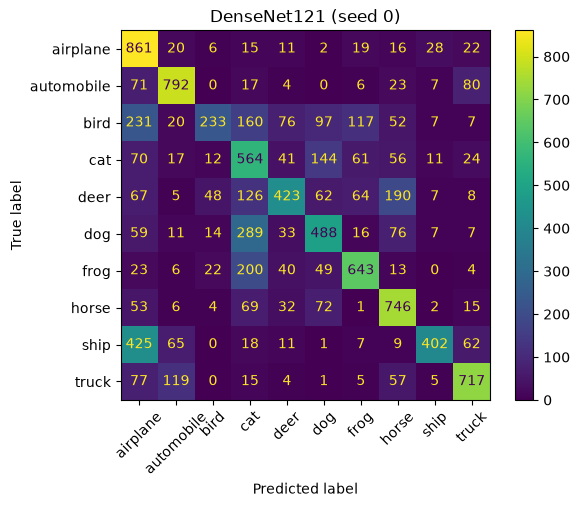

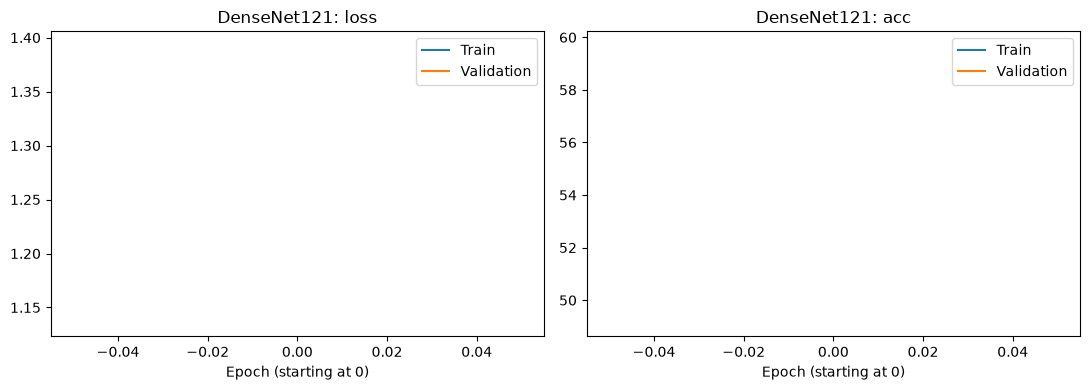


AdamW: per-class metrics and confusion matrix (representative seed 0)
airplane     precision 0.499  recall 0.352
automobile   precision 0.522  recall 0.397
bird         precision 0.316  recall 0.111
cat          precision 0.252  recall 0.151
deer         precision 0.237  recall 0.547
dog          precision 0.349  recall 0.183
frog         precision 0.295  recall 0.646
horse        precision 0.490  recall 0.285
ship         precision 0.368  recall 0.444
truck        precision 0.427  recall 0.330


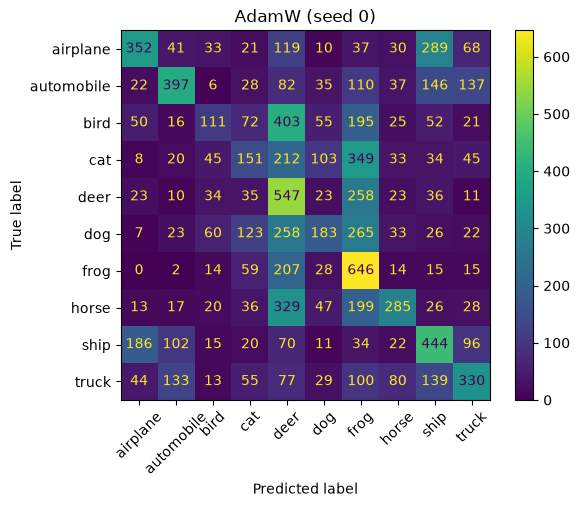

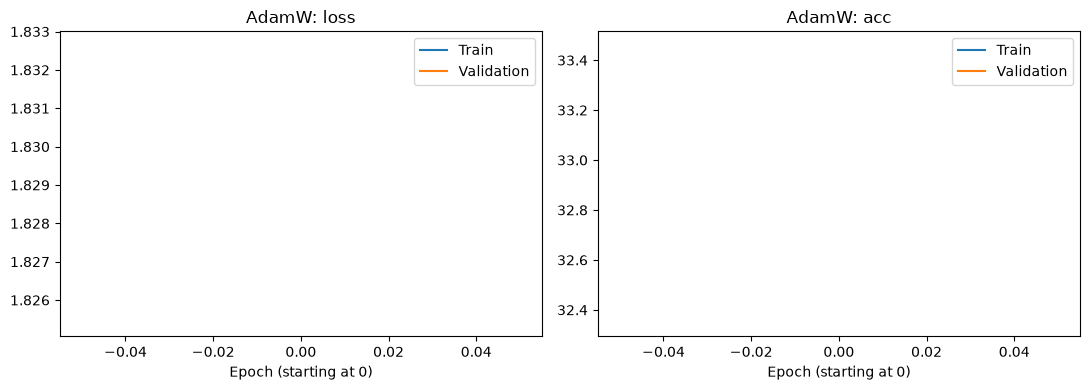

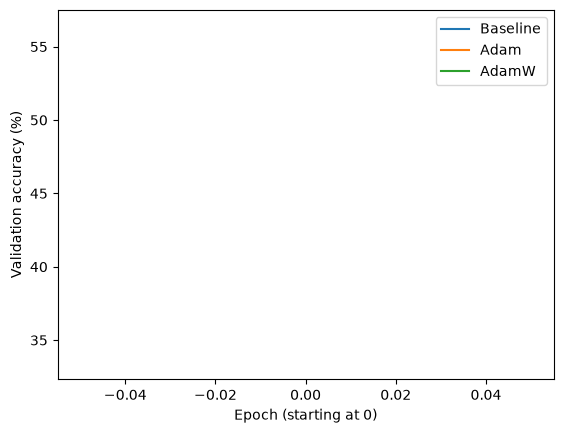

In [13]:
# Run seven configurations x three seeds; one CSV row per completed run.
results, histories, predictions = [], {}, {}
with open("results.csv", "w", newline="") as file:
    writer = None
    for config_name, config in configurations.items():
        for seed in experiment_seeds:
            result, history, test_predictions = run_experiment(config_name, config, seed)
            histories[(config_name, seed)] = history
            predictions[(config_name, seed)] = test_predictions
            results.append(result)
            if writer is None:
                writer = csv.DictWriter(file, fieldnames=[*result, "history"])
                writer.writeheader()
            writer.writerow({**result, "history": json.dumps(history)})
            file.flush()
            print(f"{config_name} seed {seed}: test acc {result['accuracy']:.2f}%, "
                  f"macro-F1 {result['macro_f1']:.3f}")

studies = {
    "Architecture": ["Baseline", "ResNet18", "DenseNet121"],
    "Augmentation": ["Baseline", "Aug1", "Aug2"],
    "Optimiser": ["Baseline", "Adam", "AdamW"],
}
# Sample standard deviation (ddof=1), computed from three separate test evaluations.
for study, names in studies.items():
    print(f"\n{study}: configuration | parameters | accuracy (%) | macro-F1 | training seconds")
    for name in names:
        runs = [row for row in results if row["configuration"] == name]
        accs = [row["accuracy"] for row in runs]
        f1s = [row["macro_f1"] for row in runs]
        print(f"{name:12} | {runs[0]['params']:>10} | "
              f"{np.mean(accs):.2f} ± {np.std(accs, ddof=1):.2f} | "
              f"{np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f} | "
              f"{np.mean([row['train_seconds'] for row in runs]):.1f}")

# Choose representative configurations using validation loss, not test results.
mean_val_loss = {name: np.mean([row["best_val_loss"] for row in results
                                if row["configuration"] == name]) for name in configurations}
best_name = min(mean_val_loss, key=mean_val_loss.get)
worst_name = max(mean_val_loss, key=mean_val_loss.get)
for name in [best_name, worst_name]:
    print(f"\n{name}: per-class metrics and confusion matrix (representative seed {experiment_seeds[0]})")
    test_predictions = predictions[(name, experiment_seeds[0])]
    precision, recall, _, _ = precision_recall_fscore_support(
        testset.targets, test_predictions, labels=list(range(10)), zero_division=0
    )
    for class_name, p, r in zip(testset.classes, precision, recall):
        print(f"{class_name:12} precision {p:.3f}  recall {r:.3f}")
    ConfusionMatrixDisplay.from_predictions(
        testset.targets, test_predictions, display_labels=testset.classes, xticks_rotation=45
    )
    plt.title(f"{name} (seed {experiment_seeds[0]})")
    plt.show()

    history = histories[(name, experiment_seeds[0])]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for metric, ax in [("loss", axes[0]), ("acc", axes[1])]:
        ax.plot(history[f"train_{metric}"], label="Train")
        ax.plot(history[f"val_{metric}"], label="Validation")
        ax.set(xlabel="Epoch (starting at 0)", title=f"{name}: {metric}")
        ax.legend()
    plt.tight_layout()
    plt.show()

# Compare optimiser convergence using the same representative seed.
for name in studies["Optimiser"]:
    plt.plot(histories[(name, experiment_seeds[0])]["val_acc"], label=name)
plt.xlabel("Epoch (starting at 0)")
plt.ylabel("Validation accuracy (%)")
plt.legend()
plt.show()